# ALMA implementation checks
Run cells in order. Synthetic checks run without MCFOST or a model directory. The observation path below is retained from the original notebook; enter `MODEL_DIR` manually when a model is available.

These checks exercise the current source implementations of `alma_image_spec`, `convolve_alma_to_jybeam`, and `compare_alma_images`, plus FITS loading, resampling and cropping. They do not run SMAC or MCFOST, alter observations, change the objective, or establish astrophysical alignment. Temporary diagnostic files are removed when the temporary directory is closed or the kernel exits.

In [1]:
import ast
import importlib.util
import os
import sys
import tempfile
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.constants import c
from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import convolve_fft
from radio_beam import Beam
from skimage.transform import rescale
from IPython.display import display, Image

REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "lib/obriy_alma.py").is_file()), None)
if REPO is None:
    raise RuntimeError("Run this notebook from the repository or a subdirectory.")
sys.path.insert(0, str(REPO))
print("Python:", sys.executable)

if importlib.util.find_spec("distroi") is not None:
    import importlib
    import lib.obriy_alma as oba
    oba = importlib.reload(oba)
    print("Using full lib.obriy_alma module.")
else:
    # Execute selected, unchanged function definitions from the actual source.
    # This bypasses module-level distroi imports, not any ALMA function logic.
    import fnmatch
    import subprocess
    names = {"alma_image_spec", "Loadimage_alma", "load_mcfost_image_alma_casa",
             "rescale_alma", "cut_down_alma", "convolve_alma_to_jybeam",
             "compare_alma_images", "alma_snr_aperture_radius"}
    tree = ast.parse((REPO / "lib/obriy_alma.py").read_text())
    selected = [n for n in tree.body if isinstance(n, ast.FunctionDef) and n.name in names]
    assert {n.name for n in selected} == names
    namespace = dict(globals())
    namespace.update(__import__("typing").__dict__)
    exec(compile(ast.Module(body=selected, type_ignores=[]),
                 str(REPO / "lib/obriy_alma.py"), "exec"), namespace)
    oba = SimpleNamespace(**{name: namespace[name] for name in names})
    print("Standalone ALMA mode: actual source functions; full module import not tested (distroi absent).")

scratch = tempfile.TemporaryDirectory(prefix="alma_checks_")
OUTPUT_DIR = Path(scratch.name)
print("Temporary outputs:", OUTPUT_DIR)


Python: /opt/anaconda3/envs/interferometry/bin/python


/Users/katerynaandrych/Work/lin/python scripts/modelling_optimisation/lib/obriy_alma.py:229: SyntaxWarning: invalid escape sequence '\m'
  plt.suptitle(str(wave)+"$\mu m$, "+title_addition)


Using full lib.obriy_alma module.
Temporary outputs: /var/folders/wd/7j5253z130s18knwp68vbvpc0000gp/T/alma_checks_mmqym34i


## Paths and comparison choices
`MODEL_DIR` is the trial directory containing `data_<wavelength>/RT.fits[.gz]`, not the wavelength directory itself. Real-data cells skip until it is supplied. `CENTER_XY=None` assumes the observed FITS reference pixel is the source centre. That assumption needs visual/astrometric verification; no shift is fitted here.

With `APERTURE_RADIUS_MAS=None`, determine `max(R[observed > SNR_THRESHOLD * noise_rms]) + APERTURE_PADDING_PIXELS` on the full observation before cropping. The noise region remains independently set by `NOISE_INNER_RADIUS_MAS`. Every detected pixel counts, including isolated peaks. An aperture that cannot fit safely raises an error rather than being silently clipped.

In [5]:
OBS_FITS = Path("/Users/katerynaandrych/Work/lin/Postdoc/Data/ALMA/IRAS08544-4431/IRAS08_cont_multiscale_robust0_2mas.image.pbcor.fits")
MODEL_DIR = Path("/Users/katerynaandrych/Work/lin/Postdoc/ozstar/ozstar_model/trial_seed1562913011_budget14.10_20260805-233423")
CENTER_XY = None  # optionally (column, row), zero-based
APERTURE_RADIUS_MAS = 150  # None selects the observed SNR radius
RADIAL_BIN_WIDTH_MAS = None  # default: major-beam FWHM

MODEL_WAVELENGTH_UM = 870.0  # existing model; no spectral flux correction applied
MODEL_CENTER_XY = None  # default: native model CRPIX minus one

SNR_THRESHOLD = 3.0
APERTURE_PADDING_PIXELS = 3.0
NOISE_INNER_RADIUS_MAS = 150.0  # retain the previous background-estimation region


## Actual observation
This cell reads the original FITS file without writing to it. The identity comparison checks the diagnostic function against the real header and data; it does not validate a physical model.

In [6]:
real_observed = None
if not OBS_FITS.is_file():
    print("Set OBS_FITS to an existing observation file.")
else:
    with fits.open(OBS_FITS) as hdul:
        observed_header = hdul[0].header.copy()
        real_observed = np.asarray(hdul[0].data[0,0], dtype=float).copy()
    observed_spec = oba.alma_image_spec(observed_header)
    observed_ps = (abs(observed_header["CDELT2"])*u.Unit(observed_header["CUNIT2"])).to_value(u.mas)
    center = CENTER_XY if CENTER_XY is not None else (observed_header["CRPIX1"]-1., observed_header["CRPIX2"]-1.)
    yy, xx = np.indices(real_observed.shape)
    rr = np.hypot(xx-center[0], yy-center[1])*observed_ps
    noise_rms = float(np.nanstd(real_observed[rr > NOISE_INNER_RADIUS_MAS]))
    comparison_radius_mas = APERTURE_RADIUS_MAS
    if comparison_radius_mas is None:
        radius_pixels = oba.alma_snr_aperture_radius(
            real_observed, noise_rms, center_xy=center,
            snr_threshold=SNR_THRESHOLD, padding_pixels=APERTURE_PADDING_PIXELS)
        comparison_radius_mas = radius_pixels * observed_ps
    print(f"Comparison aperture: {comparison_radius_mas / observed_ps:.3f} pixels = {comparison_radius_mas:.3f} mas")
    # Same background-RMS approach as the current pipeline; check for source contamination.
    display(pd.Series(observed_spec))
    print("Array:", real_observed.shape, "centre:", center, "background RMS:", noise_rms, "Jy/beam")
    if np.all(np.isfinite(real_observed)):
        actual_identity = oba.compare_alma_images(real_observed,real_observed,observed_header,observed_ps,
            center_xy=center,aperture_radius_mas=comparison_radius_mas)
        assert actual_identity["residual_rms_jybeam"] == 0.
        print("PASS: real-observation identity check; aperture flux:", actual_identity["observed_flux_jy"], "Jy")
    else:
        print("Identity check skipped: nonfinite observation pixels need inspection.")


Comparison aperture: 75.000 pixels = 150.000 mas


frequency_hz      3.529471e+11
wavelength_um     8.493977e+02
npix              5.620000e+02
pixel_mas         1.000000e+00
fov_mas           5.620000e+02
beam_major_mas    1.106214e+01
beam_minor_mas    9.441578e+00
beam_pa_deg      -2.860233e+01
dtype: float64

Array: (256, 256) centre: (128.0, 128.0) background RMS: 7.275439700204531e-05 Jy/beam
PASS: real-observation identity check; aperture flux: 0.2907716772344335 Jy


## Existing 870 µm model: convolution and aperture comparison
The existing model need not match the new simulation dimensions or wavelength. Discover it by FITS `WAVE`, convolve on its native grid, and verify coverage of the central comparison region plus five beam sigma.

The comparison uses an integer crop of the observation and samples the convolved model at those observation pixel centres. **Explicit alignment assumption:** the model reference pixel corresponds to `CENTER_XY` (by default the observation reference pixel). This is not a fitted astrometric offset. `MODEL_CENTER_XY` can override the native model centre. The mapping is a local tangent-plane approximation appropriate to this small field and rejects rotated/flipped observation grids. It avoids integer centre-crop offsets and preserves Jy/beam surface brightness.

The 870 µm versus observed wavelength difference is printed and left uncorrected. Scores are aperture diagnostics, not the full production objective. Original FITS files are read only.

Model: /Users/katerynaandrych/Work/lin/Postdoc/ozstar/ozstar_model/trial_seed1562913011_budget14.10_20260805-233423/data_870.0/RT.fits
Wavelengths: model 870.000 µm; observation 849.398 µm (no spectral correction)
Native shape: (600, 600) pixel: 0.68306004 mas
Comparison shape: (153, 153) model margin: 52.576481979987854 mas
Assumed aligned centres: native model [300. 300.] → observed (128.0, 128.0)
Centre in comparison crop: (76.0, 76.0)
PASS: point-source flux through actual grid mapping = 1.001830 Jy


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


residual_energy_loss            53.917703
observed_energy                  0.013881
residual_energy                  0.007485
aperture_pixel_count                17645
observed_flux_jy                 0.290772
model_flux_jy                    0.070203
flux_difference_jy              -0.220569
model_to_observed_flux           0.241436
residual_rms_jybeam              0.000651
aperture_radius_mas                 150.0
aperture_radius_pixels               75.0
aperture_selection        explicit_radius
dtype: object

,radius_mas,observed_jybeam,model_jybeam
0,5.531071,0.002981,3.110042e-03
1,16.593212,0.002818,1.791566e-03
2,27.655354,0.002294,8.709003e-04
3,38.717495,0.001830,4.671031e-04
4,49.779637,0.001492,2.565172e-04
5,60.841778,0.001158,1.341551e-04
6,71.903920,0.000862,5.669986e-05
7,82.966061,0.000499,2.497774e-05
8,94.028203,0.000228,1.144610e-05
9,105.090344,0.000109,6.852121e-06


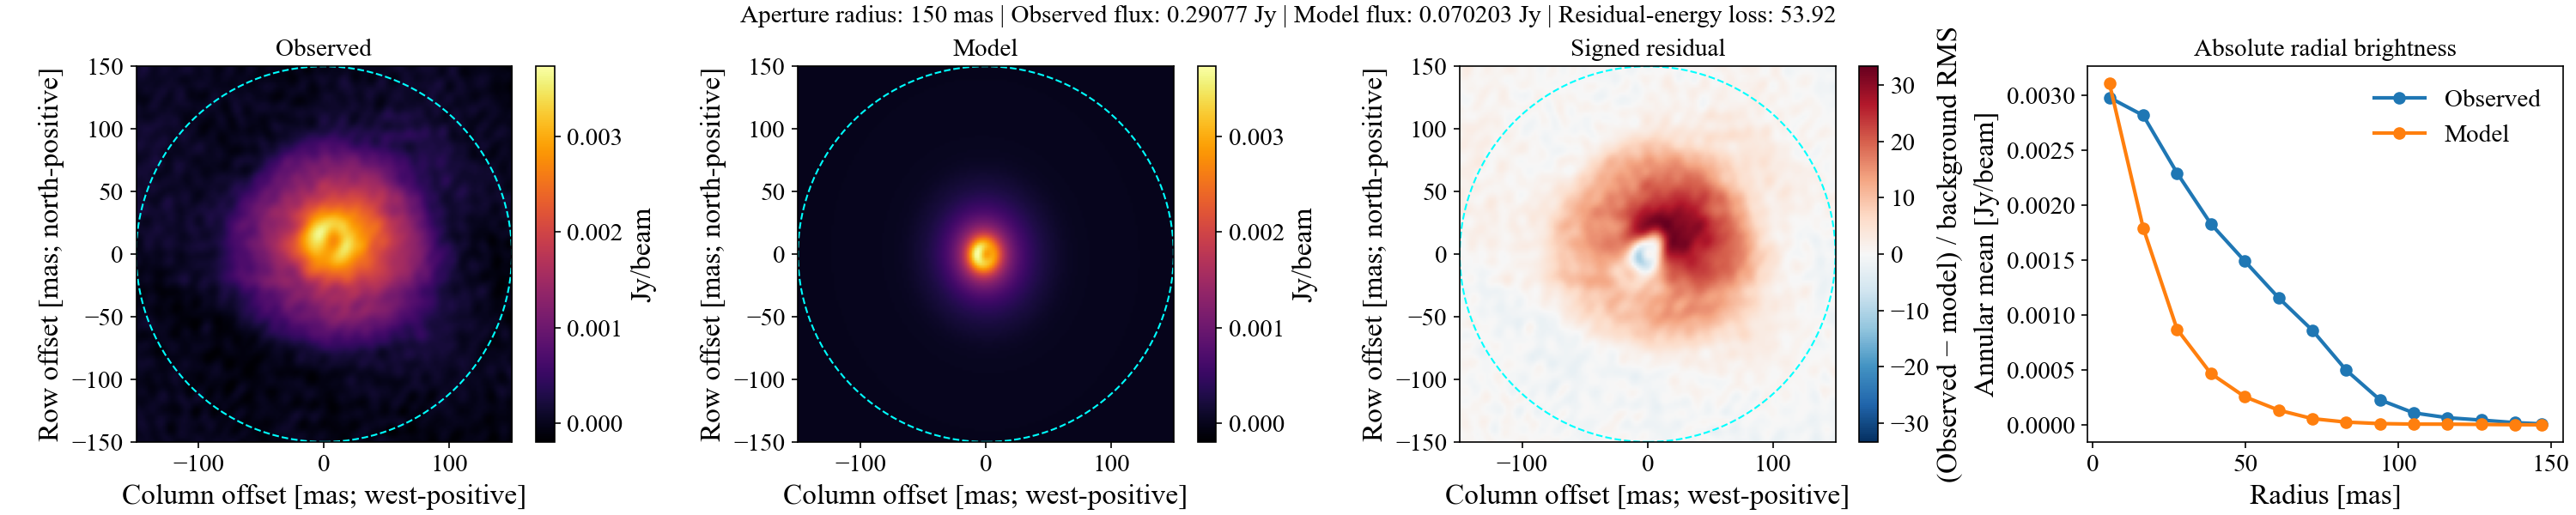

Aperture residual-energy diagnostic (x100, not production objective): 53.91770335737762


In [7]:
from scipy.ndimage import map_coordinates

model_comparison = None
if MODEL_DIR is None:
    print("SKIPPED: enter MODEL_DIR in the paths cell.")
elif real_observed is None:
    print("SKIPPED: load the observation first.")
else:
    trial_dir = Path(MODEL_DIR).expanduser()
    candidates = []
    for directory in sorted(trial_dir.glob("data_*")):
        path = directory / "RT.fits"
        if not path.is_file():
            path = directory / "RT.fits.gz"
        if path.is_file():
            hdr = fits.getheader(path)
            if np.isclose(float(hdr.get("WAVE", np.nan)), MODEL_WAVELENGTH_UM,
                          rtol=0., atol=0.001):
                candidates.append(path)
    if len(candidates) != 1:
        raise ValueError(f"Expected one image at {MODEL_WAVELENGTH_UM} micron; found {candidates}")
    model_path = candidates[0]
    with fits.open(model_path) as hdul:
        model_header = hdul[0].header.copy()
        model_native = np.asarray(hdul[0].data[0,0], dtype=float).copy()
    model_beam, model_ps = oba.convolve_alma_to_jybeam(
        model_native, model_header, observed_header)
    beam = Beam.from_fits_header(observed_header)
    print("Model:", model_path)
    print(f"Wavelengths: model {model_header['WAVE']:.3f} µm; observation {observed_spec['wavelength_um']:.3f} µm (no spectral correction)")
    print("Native shape:", model_native.shape, "pixel:", model_ps, "mas")

    obs_matrix = WCS(observed_header).celestial.pixel_scale_matrix
    expected_matrix = np.diag([-observed_ps, observed_ps]) / 3600000.
    if not np.allclose(obs_matrix, expected_matrix, rtol=1e-6, atol=1e-12):
        raise ValueError("Observation grid is not square and west-right/north-up.")
    model_center = np.asarray(MODEL_CENTER_XY if MODEL_CENTER_XY is not None else
        (model_header["CRPIX1"]-1., model_header["CRPIX2"]-1.), dtype=float)
    # Crop the data at integer pixel boundaries, retaining the chosen centre.
    radius_pixels = comparison_radius_mas / observed_ps
    x0 = int(np.floor(center[0] - radius_pixels)) - 1
    x1 = int(np.ceil(center[0] + radius_pixels)) + 2
    y0 = int(np.floor(center[1] - radius_pixels)) - 1
    y1 = int(np.ceil(center[1] + radius_pixels)) + 2
    if x0 < 0 or y0 < 0 or x1 > real_observed.shape[1] or y1 > real_observed.shape[0]:
        raise ValueError("Observation does not cover the requested comparison crop.")
    observed_matched = real_observed[y0:y1, x0:x1].copy()
    comparison_center = (center[0]-x0, center[1]-y0)
    yy, xx = np.indices(observed_matched.shape, dtype=float)
    native_x = model_center[0] + (xx+x0-center[0])*observed_ps/model_ps
    native_y = model_center[1] + (yy+y0-center[1])*observed_ps/model_ps
    padding_mas = 5*beam.major.to_value(u.mas)/np.sqrt(8*np.log(2))
    remaining_margin = min(native_x.min()+0.5,
        model_native.shape[1]-0.5-native_x.max(), native_y.min()+0.5,
        model_native.shape[0]-0.5-native_y.max())*model_ps
    if remaining_margin < padding_mas:
        raise ValueError(f"Insufficient model margin: {remaining_margin:.2f} mas; need {padding_mas:.2f} mas.")
    # Linear interpolation of the beam-smoothed brightness; no flux rescaling.
    model_matched = map_coordinates(model_beam, [native_y,native_x],
        order=1, mode="constant", cval=np.nan, prefilter=False)
    assert np.all(np.isfinite(model_matched))
    assert model_matched.shape == observed_matched.shape
    print("Comparison shape:", observed_matched.shape, "model margin:", remaining_margin, "mas")
    print("Assumed aligned centres: native model", model_center, "→ observed", center)
    print("Centre in comparison crop:", comparison_center)

    # Validate this exact interpolation/cropping mapping with a 1 Jy point source.
    # Fractional model centres are deposited bilinearly, preserving flux and centroid.
    point_check = np.zeros_like(model_native)
    ix, iy = np.floor(model_center).astype(int)
    fx, fy = model_center - [ix,iy]
    for ox, wx in [(0,1-fx),(1,fx)]:
        for oy, wy in [(0,1-fy),(1,fy)]:
            point_check[iy+oy,ix+ox] += wx*wy
    point_convolved, _ = oba.convolve_alma_to_jybeam(point_check,model_header,observed_header)

    point_sampled = map_coordinates(point_convolved,[native_y,native_x],
        order=1,mode="constant",cval=np.nan,prefilter=False)
    aperture = np.hypot(xx-comparison_center[0], yy-comparison_center[1])*observed_ps < comparison_radius_mas
    pixel_factor = ((observed_ps*u.mas)**2/beam.sr).to_value(u.dimensionless_unscaled)
    test_flux = point_sampled[aperture].sum()*pixel_factor
    assert np.isclose(test_flux,1.,rtol=0.01), test_flux
    print(f"PASS: point-source flux through actual grid mapping = {test_flux:.6f} Jy")

    result_path = OUTPUT_DIR / "existing_870um_comparison.png"
    model_comparison = oba.compare_alma_images(observed_matched,model_matched,
        observed_header,observed_ps,center_xy=comparison_center,
        aperture_radius_mas=comparison_radius_mas,
        radial_bin_width_mas=RADIAL_BIN_WIDTH_MAS,
        noise_rms_jybeam=noise_rms,save_path=result_path)
    display(pd.Series({k:v for k,v in model_comparison.items() if not isinstance(v,np.ndarray)}))
    display(pd.DataFrame({"radius_mas":model_comparison["radius_mas"],
        "observed_jybeam":model_comparison["observed_profile_jybeam"],
        "model_jybeam":model_comparison["model_profile_jybeam"]}))
    display(Image(filename=str(result_path)))
    denominator = np.sum(observed_matched[aperture]**2)
    if denominator <= 0: raise ValueError("Zero observed aperture energy.")
    aperture_loss = 100*np.sum((model_matched[aperture]-observed_matched[aperture])**2)/denominator
    print("Aperture residual-energy diagnostic (x100, not production objective):", float(aperture_loss))


## Optional legacy profile diagnostic
`chi2_ALMA` remains a separate, normalised-profile diagnostic. Its shared PDI profile helper has placeholder/zero errors in some paths, so this is only an execution check, not validation of a statistical chi-square. It requires the full repository imports (`distroi`). The new absolute radial profile above does not depend on it.
This legacy helper uses the geometric crop centre rather than an explicit centre; for a fractional user-selected centre, prefer the absolute profiles above.

In [8]:
if model_comparison is None:
    print("SKIPPED: supply a model first.")
elif not hasattr(oba,"chi2_ALMA"):
    print("SKIPPED: full repository imports require distroi in this Python environment.")
else:
    import lib.obriy_polarimetry as obp
    radial, azimuthal = obp.profiles(observed_matched,observed_ps,
        profile_type="both",mode="mean",radial_limit_mas=100.,plot=False,
        deprojection_inc_pa_deg=(0.,0.),center=None,az_nbins=18,
        azimuthal_r_in_mas=0.,azimuthal_r_out_mas=100.,theta0=0.)
    legacy_data = {"alma_cont":observed_matched,"radial_profile":radial,
        "azimuthal_profile":azimuthal,"ps_alma":observed_ps,"image_spec":observed_spec}
    legacy_result = oba.chi2_ALMA(str(OUTPUT_DIR),legacy_data,model_matched,
        plot=False,fig_dir=str(OUTPUT_DIR / "legacy_profiles"))
    print("Legacy profile diagnostic (not used in the objective):",legacy_result)


Chi2: 3.5674934134497704e+16, Reduced Chi2: 775542046402124.0, Log-Likelihood: -1.7837467067248026e+16, Data points: 47
Chi2: 20.685335004181123, Reduced Chi2: 1.2167844120106543, Log-Likelihood: 1.7717688183460134, Data points: 18
Legacy profile diagnostic (not used in the objective): (np.float64(566268795785678.1), np.float64(3.5674934134497704e+16), np.float64(20.685335004181123), 47, 18)


## Interpretation
- The existing model is at 870 µm; the observation is approximately 849.398 µm. No spectral scaling is fitted.
- Beam convolution and Jy/pixel → Jy/beam conversion use the actual model header and observational beam.
- The model is sampled onto a central observational crop under an explicit reference-centre alignment assumption. This does not establish the true astrometric centre.
- Fluxes and absolute radial profiles refer to the same observation-selected aperture. The aperture residual-energy diagnostic is not the production ≥3σ-mask objective.
- The production diagnostic aperture also uses the observed SNR rule; the optimisation loss and weights are unchanged.
- The optional older profile χ² remains a normalised diagnostic with unvalidated uncertainties.
